### 6505035 สลิลทิพย์ ประยูรวรวงศ์

In [3]:
import pandas as pd

In [4]:
import os
os.getcwd()

'c:\\Users\\user\\Documents\\UNI\\YEAR_4\\PSHD 3112\\AI'

# Import Data

In [5]:
# Read file tsv
# file = pd.read_csv("/drive/notebooks/BRCA_Doxorubicin_isR_RPM.tsv", sep = "\t") 
# file = pd.read_csv("/drive/notebooks/BRCA_Doxorubicin_mRNA_FPKM.tsv", sep = "\t") 
# file = pd.read_csv("/drive/notebooks/BRCA_Doxorubicin_miRNA_RPM_UQ.tsv", sep = "\t") 
# file = pd.read_csv("/drive/notebooks/BRCA_Doxorubicin_CNV_mean.tsv", sep = "\t") 
file = pd.read_csv(r"Data\BRCA_Doxorubicin_miRNA_RPM_UQ.tsv", sep = "\t") 
file

,Patient,response,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,...,hsa-mir-940,hsa-mir-941-1,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
0,TCGA-4H-AAAK-01A-12R-A41G-13,Responder,14576.349859,14567.992759,14659.398543,22130.472094,3240.987956,355.002656,1670.201314,4116.045998,...,0.174106,0.0,1.915169,0.0,1.218744,0.870531,20.196326,34.124826,1055.780336,25479.928247
1,TCGA-5T-A9QA-01A-11R-A41G-13,Responder,18058.297406,17976.645892,18162.136832,34903.063973,446.420779,492.275796,2207.845113,3846.792175,...,1.775033,0.0,19.229523,0.0,0.887516,6.804293,49.700922,40.529918,116.560495,34969.627708
2,TCGA-A2-A0CR-01A-11R-A22I-13,Responder,7011.396133,6956.577590,6970.767676,15361.738898,2659.520838,189.400305,386.717183,2222.466192,...,1.344324,0.0,5.377296,0.0,1.493693,2.539279,48.843769,40.030979,1119.074986,14755.598176
3,TCGA-A2-A0EP-01A-52R-A22V-13,Responder,11039.937761,10936.798937,11068.104607,26095.064676,3572.896374,357.268695,971.808547,3397.612729,...,2.094189,0.0,8.272048,0.0,1.047095,4.816635,10.575656,52.250023,1470.330311,15993.428434
4,TCGA-A2-A0EW-01A-21R-A114-13,Non-Responder,10559.654422,10431.834671,10646.078003,33082.801780,5062.678884,373.291773,650.718732,1953.608693,...,3.631243,0.0,2.178746,0.0,1.452497,0.000000,10.893729,38.491175,2265.169336,52125.765920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,TCGA-S3-AA0Z-01A-11R-A41G-13,Responder,18957.114921,18842.988645,18948.593865,23575.527359,3611.949985,803.633378,2050.780745,6665.980326,...,1.676273,0.0,20.115280,0.0,2.235031,0.698447,10.337019,39.252734,848.613380,17532.561959
91,TCGA-S3-AA14-01A-11R-A41G-13,Responder,14569.901327,14517.142369,14597.529538,20545.867904,3233.905591,237.259219,1175.681867,3872.476292,...,1.560916,0.0,1.092641,0.0,3.434015,0.780458,39.335081,51.978500,1060.017997,14168.433754
92,TCGA-S3-AA15-01A-11R-A41G-13,Responder,7176.952375,7213.198133,7219.628832,11642.195908,2330.836079,429.395310,1014.296613,2818.107679,...,2.338436,0.0,5.553785,0.0,2.338436,3.507654,13.738311,55.830159,678.438743,26559.956037
93,TCGA-Z7-A8R5-01A-42R-A41G-13,Non-Responder,10699.639747,10638.638381,10726.480349,20388.379197,4007.000373,296.394877,943.870561,3798.878063,...,1.004728,0.0,2.152989,0.0,2.152989,1.578859,55.547127,52.820007,1112.090801,18672.877228


In [6]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Columns: 1444 entries, Patient to hsa-mir-99b
dtypes: float64(1442), str(2)
memory usage: 1.1 MB


# Data preprocessing

## Check Missing Data

In [7]:
#check if table have nan
file.isna().any().any()

False

In [8]:
file.isna().sum()

Patient         0
response        0
hsa-let-7a-1    0
hsa-let-7a-2    0
hsa-let-7a-3    0
               ..
hsa-mir-95      0
hsa-mir-96      0
hsa-mir-98      0
hsa-mir-99a     0
hsa-mir-99b     0
Length: 1444, dtype: int64

In [9]:
# Count vaues in column
file['response'].value_counts()

response
Responder        86
Non-Responder     9
Name: count, dtype: int64

## Label Encoding

In [10]:
# Label encoding --> Convert Responder to 1; Non-responder to 0 
file['response'] = file['response'].map({'Responder': 1, 'Non-Responder': 0})
file

,Patient,response,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,...,hsa-mir-940,hsa-mir-941-1,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
0,TCGA-4H-AAAK-01A-12R-A41G-13,1,14576.349859,14567.992759,14659.398543,22130.472094,3240.987956,355.002656,1670.201314,4116.045998,...,0.174106,0.0,1.915169,0.0,1.218744,0.870531,20.196326,34.124826,1055.780336,25479.928247
1,TCGA-5T-A9QA-01A-11R-A41G-13,1,18058.297406,17976.645892,18162.136832,34903.063973,446.420779,492.275796,2207.845113,3846.792175,...,1.775033,0.0,19.229523,0.0,0.887516,6.804293,49.700922,40.529918,116.560495,34969.627708
2,TCGA-A2-A0CR-01A-11R-A22I-13,1,7011.396133,6956.577590,6970.767676,15361.738898,2659.520838,189.400305,386.717183,2222.466192,...,1.344324,0.0,5.377296,0.0,1.493693,2.539279,48.843769,40.030979,1119.074986,14755.598176
3,TCGA-A2-A0EP-01A-52R-A22V-13,1,11039.937761,10936.798937,11068.104607,26095.064676,3572.896374,357.268695,971.808547,3397.612729,...,2.094189,0.0,8.272048,0.0,1.047095,4.816635,10.575656,52.250023,1470.330311,15993.428434
4,TCGA-A2-A0EW-01A-21R-A114-13,0,10559.654422,10431.834671,10646.078003,33082.801780,5062.678884,373.291773,650.718732,1953.608693,...,3.631243,0.0,2.178746,0.0,1.452497,0.000000,10.893729,38.491175,2265.169336,52125.765920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,TCGA-S3-AA0Z-01A-11R-A41G-13,1,18957.114921,18842.988645,18948.593865,23575.527359,3611.949985,803.633378,2050.780745,6665.980326,...,1.676273,0.0,20.115280,0.0,2.235031,0.698447,10.337019,39.252734,848.613380,17532.561959
91,TCGA-S3-AA14-01A-11R-A41G-13,1,14569.901327,14517.142369,14597.529538,20545.867904,3233.905591,237.259219,1175.681867,3872.476292,...,1.560916,0.0,1.092641,0.0,3.434015,0.780458,39.335081,51.978500,1060.017997,14168.433754
92,TCGA-S3-AA15-01A-11R-A41G-13,1,7176.952375,7213.198133,7219.628832,11642.195908,2330.836079,429.395310,1014.296613,2818.107679,...,2.338436,0.0,5.553785,0.0,2.338436,3.507654,13.738311,55.830159,678.438743,26559.956037
93,TCGA-Z7-A8R5-01A-42R-A41G-13,0,10699.639747,10638.638381,10726.480349,20388.379197,4007.000373,296.394877,943.870561,3798.878063,...,1.004728,0.0,2.152989,0.0,2.152989,1.578859,55.547127,52.820007,1112.090801,18672.877228


In [11]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Columns: 1444 entries, Patient to hsa-mir-99b
dtypes: float64(1442), int64(1), str(1)
memory usage: 1.0 MB


## Seperate Target Column

In [12]:
# Define X and y
X = file.drop(columns=['response']).set_index(file.columns[0])
y = file['response']

In [13]:
X

,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,hsa-let-7g,...,hsa-mir-940,hsa-mir-941-1,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
Patient,,,,,,,,,,,,,,,,,,,,,
TCGA-4H-AAAK-01A-12R-A41G-13,14576.349859,14567.992759,14659.398543,22130.472094,3240.987956,355.002656,1670.201314,4116.045998,4187.603669,332.194736,...,0.174106,0.0,1.915169,0.0,1.218744,0.870531,20.196326,34.124826,1055.780336,25479.928247
TCGA-5T-A9QA-01A-11R-A41G-13,18058.297406,17976.645892,18162.136832,34903.063973,446.420779,492.275796,2207.845113,3846.792175,3973.411190,770.955965,...,1.775033,0.0,19.229523,0.0,0.887516,6.804293,49.700922,40.529918,116.560495,34969.627708
TCGA-A2-A0CR-01A-11R-A22I-13,7011.396133,6956.577590,6970.767676,15361.738898,2659.520838,189.400305,386.717183,2222.466192,2276.985996,541.314435,...,1.344324,0.0,5.377296,0.0,1.493693,2.539279,48.843769,40.030979,1119.074986,14755.598176
TCGA-A2-A0EP-01A-52R-A22V-13,11039.937761,10936.798937,11068.104607,26095.064676,3572.896374,357.268695,971.808547,3397.612729,3418.449912,742.285399,...,2.094189,0.0,8.272048,0.0,1.047095,4.816635,10.575656,52.250023,1470.330311,15993.428434
TCGA-A2-A0EW-01A-21R-A114-13,10559.654422,10431.834671,10646.078003,33082.801780,5062.678884,373.291773,650.718732,1953.608693,2045.116015,333.348100,...,3.631243,0.0,2.178746,0.0,1.452497,0.000000,10.893729,38.491175,2265.169336,52125.765920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-S3-AA0Z-01A-11R-A41G-13,18957.114921,18842.988645,18948.593865,23575.527359,3611.949985,803.633378,2050.780745,6665.980326,6781.782876,981.458042,...,1.676273,0.0,20.115280,0.0,2.235031,0.698447,10.337019,39.252734,848.613380,17532.561959
TCGA-S3-AA14-01A-11R-A41G-13,14569.901327,14517.142369,14597.529538,20545.867904,3233.905591,237.259219,1175.681867,3872.476292,3971.282269,447.046318,...,1.560916,0.0,1.092641,0.0,3.434015,0.780458,39.335081,51.978500,1060.017997,14168.433754
TCGA-S3-AA15-01A-11R-A41G-13,7176.952375,7213.198133,7219.628832,11642.195908,2330.836079,429.395310,1014.296613,2818.107679,2913.106641,593.670438,...,2.338436,0.0,5.553785,0.0,2.338436,3.507654,13.738311,55.830159,678.438743,26559.956037


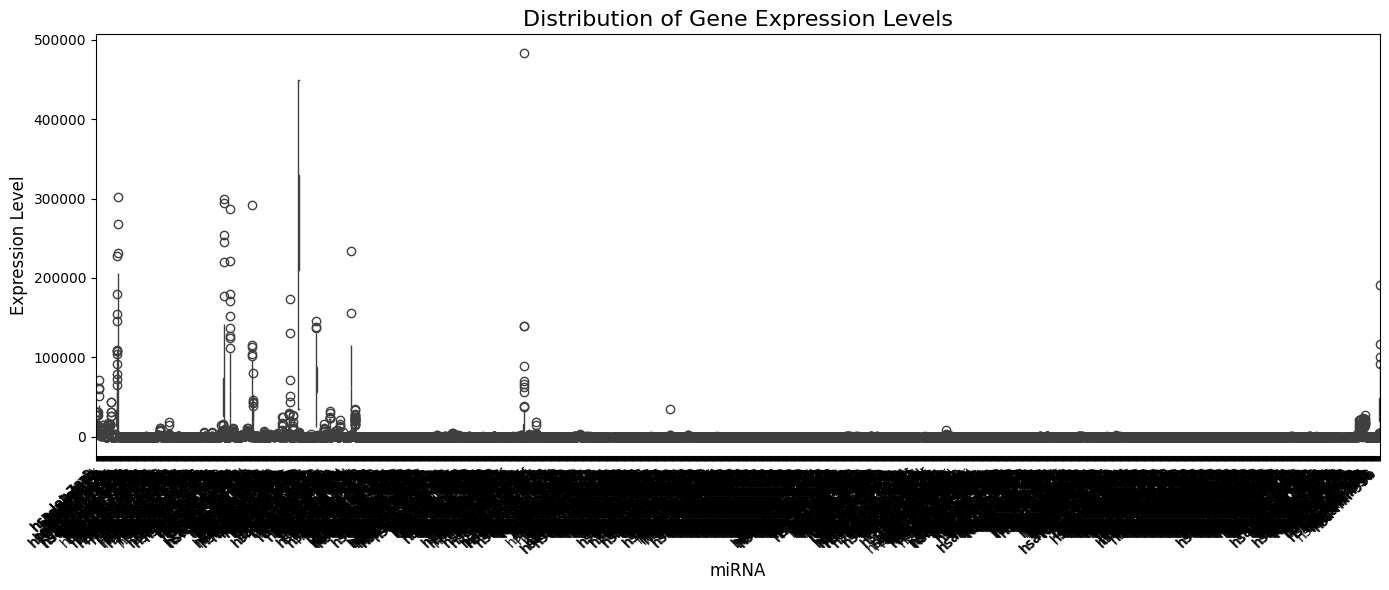

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


target_cols = [col for col in file.columns if col.startswith('hsa-')]

# Check if any columns matched to avoid plotting errors
if not target_cols:
    print("No columns starting with 'hsa-mir' found. Please check your column names.")
else:
    # 3. Set up the plot size (make it wider if you have many miRNAs)
    plt.figure(figsize=(14, 6))
    
    # 4. Create the box plot using seaborn
    # We pass only the filtered columns to the data argument
    sns.boxplot(data=file[target_cols])
    
    # 5. Formatting for readability
    plt.title('Distribution of Gene Expression Levels', fontsize=16)
    plt.ylabel('Expression Level', fontsize=12)
    plt.xlabel('miRNA', fontsize=12)
    
    # Rotate the x-axis labels by 45 degrees so the names don't overlap
    plt.xticks(rotation=45, ha='right') 
    
    # Adjust layout so nothing gets cut off
    plt.tight_layout()
    
    # 6. Display the plot
    plt.show()

## Data scaler

In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Select only numerical columns (scaling text/labels will throw an error)
num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# 3. Fit and transform the data
X[num_cols] = scaler.fit_transform(X[num_cols])

print(X.head())

                              hsa-let-7a-1  hsa-let-7a-2  hsa-let-7a-3  \
Patient                                                                  
TCGA-4H-AAAK-01A-12R-A41G-13      0.653081      0.659335      0.659185   
TCGA-5T-A9QA-01A-11R-A41G-13      1.351831      1.344997      1.361024   
TCGA-A2-A0CR-01A-11R-A22I-13     -0.865038     -0.871727     -0.881377   
TCGA-A2-A0EP-01A-52R-A22V-13     -0.056598     -0.071092     -0.060399   
TCGA-A2-A0EW-01A-21R-A114-13     -0.152981     -0.172667     -0.144959   

                              hsa-let-7b  hsa-let-7c  hsa-let-7d  hsa-let-7e  \
Patient                                                                        
TCGA-4H-AAAK-01A-12R-A41G-13    0.003152    0.043394   -0.578538    0.500314   
TCGA-5T-A9QA-01A-11R-A41G-13    1.113048   -1.211759   -0.167536    1.214600   
TCGA-A2-A0CR-01A-11R-A22I-13   -0.585029   -0.217767   -1.074359   -1.204858   
TCGA-A2-A0EP-01A-52R-A22V-13    0.347662    0.192467   -0.571754   -0.427535   
T

In [16]:
X = X.to_numpy() 
X

array([[ 0.65308131,  0.65933489,  0.65918473, ..., -0.86840107,
         0.12756872, -0.49670124],
       [ 1.35183123,  1.34499711,  1.36102421, ..., -0.69947351,
        -1.11795767, -0.14835213],
       [-0.86503772, -0.87172726, -0.88137703, ..., -0.7126325 ,
         0.21150557, -0.89037134],
       ...,
       [-0.83181424, -0.82010716, -0.83151302, ..., -0.29594575,
        -0.3728348 , -0.45705544],
       [-0.12488874, -0.13106816, -0.12884938, ..., -0.37533534,
         0.20224365, -0.74657535],
       [ 0.54536878,  0.54159222,  0.53386738, ...,  0.32168774,
        -0.66263229, -0.1914788 ]])

In [17]:
y

0     1
1     1
2     1
3     1
4     0
     ..
90    1
91    1
92    1
93    0
94    1
Name: response, Length: 95, dtype: int64

# Modeling

In [18]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn import tree
from sklearn.metrics import matthews_corrcoef, make_scorer

In [19]:
np.random.seed(0)

## Decision Tree

In [20]:
# Define model
decisiontree_model = tree.DecisionTreeClassifier(random_state=2215104) #75434668, 38712131, 60969723, 58554051

In [21]:
# Define metric
mcc_scorer = make_scorer(matthews_corrcoef)

In [22]:
# Define cross-validation method --> 10-Fold cross-validation
cv = StratifiedKFold(n_splits=10)

In [23]:
# Train and test model
scores = cross_val_score(decisiontree_model, X, y, cv=cv, scoring=mcc_scorer)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


In [24]:
# Print result
print("MCC for each fold:", scores)
print("Average 10-Fold MCC:", np.mean(scores))

MCC for each fold: [ 1.          0.          1.          0.50917508 -0.11111111  0.
 -0.125      -0.18898224  0.          0.        ]
Average 10-Fold MCC: 0.2084081729601591


In [25]:
# More metrics
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define Metrics
scoring = {
    'auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
    'accuracy': 'accuracy',
    'precision': 'precision',
    'sensitivity': 'recall' # Recall is Sensitivity
}

# 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10)
scores = cross_validate(decisiontree_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

# 4. Print Results
print("score for each fold:", scores)
print(f"Mean AUC: {np.mean(scores['test_auc']):.3f}")
print(f"Mean MCC: {np.mean(scores['test_mcc']):.3f}")
print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.3f}")
print(f"Mean Precision: {np.mean(scores['test_precision']):.3f}")
print(f"Mean Sensitivity/Recall: {np.mean(scores['test_sensitivity']):.3f}")


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


score for each fold: {'fit_time': array([0.02464628, 0.03132868, 0.02020836, 0.02590585, 0.02747965,
       0.02473545, 0.02345634, 0.02843118, 0.02109265, 0.01584291]), 'score_time': array([0.01616502, 0.01107597, 0.00854135, 0.01404095, 0.01114011,
       0.01308155, 0.0100975 , 0.00967026, 0.00400734, 0.01719546]), 'test_auc': array([1.        , 0.5       , 1.        , 0.88888889, 0.44444444,
              nan, 0.4375    , 0.375     , 0.5       , 0.5       ]), 'test_mcc': array([ 1.        ,  0.        ,  1.        ,  0.50917508, -0.11111111,
        0.        , -0.125     , -0.18898224,  0.        ,  0.        ]), 'test_accuracy': array([1.        , 0.9       , 1.        , 0.8       , 0.8       ,
       0.77777778, 0.77777778, 0.66666667, 0.88888889, 0.88888889]), 'test_precision': array([1.        , 0.9       , 1.        , 1.        , 0.88888889,
       1.        , 0.875     , 0.85714286, 0.88888889, 0.88888889]), 'test_sensitivity': array([1.        , 1.        , 1.        , 0.77

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [26]:
# In at least one cross-validation test fold, y_test contains only one class, such as all 0s or all 1s.
# AUC needs both classes to be present in the test set, so it cannot be computed there.
# Why this happens
    # the dataset is small
    # the positive class is rare
    # n_splits=10 is too high for your class distribution

### Untuned DT result

In [27]:
#Another way to do --> เอา prediction ของทุก fold มารวมกัน แล้วคำนวณ metric บน prediction ทั้งก้อน
# Containers for predictions
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    decisiontree_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = decisiontree_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = decisiontree_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


ROC-AUC: 0.620
MCC: 0.220
Accuracy: 0.853
Precision: 0.929
Sensitivity: 0.907


In [28]:
y

0     1
1     1
2     1
3     1
4     0
     ..
90    1
91    1
92    1
93    0
94    1
Name: response, Length: 95, dtype: int64

In [29]:
probs

array([1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [30]:
preds

array([1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### Tuned DT

In [31]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, precision_score, recall_score

# Assuming X and y are already defined as numpy arrays or pandas DataFrames

# 1. Setup the CV strategy
# IMPORTANT: With only 9 minority samples, 10 splits is safest. 
# This ensures exactly 9 non-responders end up in every test fold.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 2. Define the base model and the parameter grid to tune
dt_base = DecisionTreeClassifier(random_state=42)

# Tuning grid designed to prevent overfitting on 1442 features
param_grid = {
    'max_depth': [2, 3, 5, 8],          # Keep trees shallow so they don't memorize the data
    'min_samples_split': [5, 10, 15],   # Require more samples to make a split
    'min_samples_leaf': [2, 5, 10],     # Prevent tiny leaves with only 1 patient
    'class_weight': ['balanced', None], # Test if penalizing the majority class helps
    'criterion': ['gini', 'entropy']
}

# 3. Perform Grid Search to find the best hyperparameters
# We optimize for 'roc_auc' because accuracy is misleading for 86:9 data
print("Tuning the model... (testing different combinations)")
grid_search = GridSearchCV(
    estimator=dt_base, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1 # Uses all available computer cores to speed up the process
)

grid_search.fit(X, y)

# 4. Extract the best model from the tuning process
best_dt_model = grid_search.best_estimator_
print(f"\nBest Parameters Found: \n{grid_search.best_params_}\n")

# 5. Evaluate the BEST model using your requested Out-Of-Fold (OOF) method
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    # Depending on if X/y are pandas DataFrames or numpy arrays, 
    # you might need to use .iloc[train_idx] instead. Assuming numpy arrays here:
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit the TUNED model
    best_dt_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = best_dt_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = best_dt_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print("--- Results using the Tuned Model on Total OOF Array ---")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

Tuning the model... (testing different combinations)


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c


Best Parameters Found: 
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 5}

--- Results using the Tuned Model on Total OOF Array ---
ROC-AUC: 0.630
MCC: 0.239
Accuracy: 0.821
Precision: 0.937
Sensitivity: 0.860


## Random Forest Classifier

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=2215104)
rf_model.fit(X, y)

RandomForestClassifier(class_weight='balanced', random_state=2215104)

In [33]:
scores = cross_val_score(rf_model, X, y, cv=cv, scoring=mcc_scorer)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [34]:
# Print result
scores = cross_val_score(rf_model, X, y, cv=cv, scoring=mcc_scorer)
print("MCC for each fold:", scores)
print("Average 10-Fold MCC:", np.mean(scores))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


MCC for each fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average 10-Fold MCC: 0.0


In [35]:
# More metrics
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define Metrics
scoring = {
    'auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
    'accuracy': 'accuracy',
    'precision': 'precision',
    'sensitivity': 'recall' # Recall is Sensitivity
}

# 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10)
scores = cross_validate(rf_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

# 4. Print Results
print("score for each fold:", scores)
print(f"Mean AUC: {np.mean(scores['test_auc']):.3f}")
print(f"Mean MCC: {np.mean(scores['test_mcc']):.3f}")
print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.3f}")
print(f"Mean Precision: {np.mean(scores['test_precision']):.3f}")
print(f"Mean Sensitivity/Recall: {np.mean(scores['test_sensitivity']):.3f}")


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


score for each fold: {'fit_time': array([0.18726063, 0.17728496, 0.16795278, 0.16340661, 0.16450644,
       0.18686652, 0.19394565, 0.18049693, 0.1670754 , 0.17192268]), 'score_time': array([0.02718329, 0.02735543, 0.02394938, 0.02441764, 0.02983952,
       0.02489638, 0.03486681, 0.02693653, 0.02669239, 0.02411342]), 'test_auc': array([0.77777778, 0.61111111, 1.        , 0.88888889, 0.        ,
              nan, 0.875     , 0.625     , 0.75      , 0.875     ]), 'test_mcc': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'test_accuracy': array([0.9       , 0.9       , 0.9       , 0.9       , 0.9       ,
       1.        , 0.88888889, 0.88888889, 0.88888889, 0.88888889]), 'test_precision': array([0.9       , 0.9       , 0.9       , 0.9       , 0.9       ,
       1.        , 0.88888889, 0.88888889, 0.88888889, 0.88888889]), 'test_sensitivity': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}
Mean AUC: nan
Mean MCC: 0.000
Mean Accuracy: 0.906
Mean Precision: 0.906
Mean Sensitivity/Recal

In [36]:
#Another way to do --> เอา prediction ของทุก fold มารวมกัน แล้วคำนวณ metric บน prediction ทั้งก้อน
# Containers for predictions
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    rf_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = rf_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = rf_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


ROC-AUC: 0.645
MCC: 0.000
Accuracy: 0.905
Precision: 0.905
Sensitivity: 1.000


### Tuned RF

In [37]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, precision_score, recall_score

# 1. Setup the Pipeline
# Step 1: SelectKBest will pick the top 'k' most statistically significant features using ANOVA (f_classif)
# Step 2: Pass those selected features to a Random Forest
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 2. Define the Tuning Grid for the Pipeline
param_grid = {
    'feature_selection__k': [5, 10, 20, 50], # Test picking only the top 5, 10, 20, or 50 miRNAs
    'classifier__n_estimators': [50, 100],   # Number of trees in the forest
    'classifier__max_depth': [2, 3, 5],      # Keep trees relatively shallow
    'classifier__min_samples_split': [5, 10]
}

# 3. Setup CV (Keep it at 3 splits because of your 9 minority samples)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Tuning the Pipeline (Feature Selection + Random Forest)...")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)
best_pipeline = grid_search.best_estimator_

print(f"\nBest Parameters Found: \n{grid_search.best_params_}\n")

# 4. Evaluate using your OOF method
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit the best pipeline (this does feature selection AND modeling on the train set only)
    best_pipeline.fit(X_train, y_train)
    
    probs[test_idx] = best_pipeline.predict_proba(X_test)[:, 1]
    preds[test_idx] = best_pipeline.predict(X_test)

# Calculate Metrics
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds)

print("--- Results using Feature Selection + Random Forest ---")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

Tuning the Pipeline (Feature Selection + Random Forest)...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Best Parameters Found: 
{'classifier__max_depth': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50, 'feature_selection__k': 5}



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


--- Results using Feature Selection + Random Forest ---
ROC-AUC: 0.669
MCC: 0.240
Accuracy: 0.863
Precision: 0.929
Sensitivity: 0.919


## XGBoost

In [38]:
import xgboost as xgb

XGB_model = xgb.XGBClassifier(class_weight='balanced', random_state=2215104)
XGB_model.fit(X, y)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [39]:
scores = cross_val_score(XGB_model, X, y, cv=cv, scoring=mcc_scorer)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_we

In [40]:
# Print result
print("MCC for each fold:", scores)
print("Average 10-Fold MCC:", np.mean(scores))

MCC for each fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average 10-Fold MCC: 0.0


In [41]:
# More metrics
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define Metrics
scoring = {
    'auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
    'accuracy': 'accuracy',
    'precision': 'precision',
    'sensitivity': 'recall' # Recall is Sensitivity
}

# 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10)
scores = cross_validate(XGB_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

# 4. Print Results
print("score for each fold:", scores)
print(f"Mean AUC: {np.mean(scores['test_auc']):.3f}")
print(f"Mean MCC: {np.mean(scores['test_mcc']):.3f}")
print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.3f}")
print(f"Mean Precision: {np.mean(scores['test_precision']):.3f}")
print(f"Mean Sensitivity/Recall: {np.mean(scores['test_sensitivity']):.3f}")

#Another way to do --> เอา prediction ของทุก fold มารวมกัน แล้วคำนวณ metric บน prediction ทั้งก้อน
# Containers for predictions
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    rf_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = rf_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = rf_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_we

score for each fold: {'fit_time': array([0.18659258, 0.12382269, 0.12888956, 0.12761641, 0.15740752,
       0.24918342, 0.14161873, 0.12600446, 0.12502527, 0.13993955]), 'score_time': array([0.01211548, 0.01251101, 0.01219249, 0.01140165, 0.0170989 ,
       0.01416016, 0.01294374, 0.0134263 , 0.01357889, 0.01457   ]), 'test_auc': array([0.55555556, 0.33333333, 0.33333333, 0.55555556, 0.77777778,
              nan, 0.625     , 0.625     , 0.375     , 0.875     ]), 'test_mcc': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'test_accuracy': array([0.9       , 0.9       , 0.9       , 0.9       , 0.9       ,
       0.88888889, 0.88888889, 0.88888889, 0.88888889, 0.88888889]), 'test_precision': array([0.9       , 0.9       , 0.9       , 0.9       , 0.9       ,
       1.        , 0.88888889, 0.88888889, 0.88888889, 0.88888889]), 'test_sensitivity': array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.88888889, 1.        , 1.        , 1.        , 1.        ])}
Mean AUC

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


ROC-AUC: 0.645
MCC: 0.000
Accuracy: 0.905
Precision: 0.905
Sensitivity: 1.000


In [42]:
#Another way to do --> เอา prediction ของทุก fold มารวมกัน แล้วคำนวณ metric บน prediction ทั้งก้อน
# Containers for predictions
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    XGB_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = XGB_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = XGB_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_we

ROC-AUC: 0.528
MCC: -0.033
Accuracy: 0.895
Precision: 0.904
Sensitivity: 0.988


## Tuned XGBoost

In [43]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, precision_score, recall_score

# IMPORTANT ASSUMPTION: 
# This code assumes your target 'y' is encoded as:
# 0 = Responder (86 patients)
# 1 = Non-responder (9 patients)
# If it is reversed, you need to flip the scale_pos_weight logic below.

# Calculate the scale_pos_weight for XGBoost (Majority Class Count / Minority Class Count)
# For 86 responders and 9 non-responders, this is roughly 9.55
pos_weight = 86 / 9 

# 1. Setup the Pipeline with XGBoost
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', XGBClassifier(
        random_state=42, 
        eval_metric='logloss', # Standard evaluation metric for binary classification
        scale_pos_weight=pos_weight, # Handles the 86:9 imbalance
        use_label_encoder=False 
    ))
])

# 2. Define the Tuning Grid specifically designed to restrict XGBoost from overfitting
param_grid = {
    'feature_selection__k': [15, 20,30],   # Keep feature count low
    'classifier__n_estimators': [50, 100],     # Number of boosting rounds
    'classifier__max_depth': [1, 2, 3],        # Depth 1 = 'Stump'. Best for preventing overfitting.
    'classifier__learning_rate': [0.01, 0.05],  # Lower learning rate = more conservative model
    'classifier__subsample': [0.8],            # Only use 80% of data per tree to add randomness
    'classifier__colsample_bytree': [0.8],      # Only use 80% of features per tree to add randomness
    'classifier__min_child_weight': [0.5, 1, 2],
    'classifier__gamma': [0, 0.5]
}

# 3. Setup CV (10 splits ensures 9 non-responders in every test fold)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Tuning the Pipeline (Feature Selection + XGBoost)...")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)
best_pipeline = grid_search.best_estimator_

print(f"\nBest Parameters Found: \n{grid_search.best_params_}\n")

# 4. Evaluate using your Total OOF method
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit the best tuned pipeline
    best_pipeline.fit(X_train, y_train)
    
    # Predict
    probs[test_idx] = best_pipeline.predict_proba(X_test)[:, 1]
    preds[test_idx] = best_pipeline.predict(X_test)

# Calculate Metrics
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds)

print("--- Results using Feature Selection + Tuned XGBoost ---")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

Tuning the Pipeline (Feature Selection + XGBoost)...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan na


Best Parameters Found: 
{'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 1, 'classifier__min_child_weight': 0.5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.8, 'feature_selection__k': 15}



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-r

--- Results using Feature Selection + Tuned XGBoost ---
ROC-AUC: 0.619
MCC: 0.000
Accuracy: 0.905
Precision: 0.905
Sensitivity: 1.000


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## SVM

In [44]:

from sklearn import svm



svm_model = svm.SVC(class_weight='balanced', random_state=2215104, probability=True)
svm_model.fit(X, y)

SVC(class_weight='balanced', probability=True, random_state=2215104)

In [45]:
# Print result
scores = cross_val_score(svm_model, X, y, cv=cv, scoring=mcc_scorer)
print("MCC for each fold:", scores)
print("Average 10-Fold MCC:", np.mean(scores))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


MCC for each fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average 10-Fold MCC: 0.0


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [46]:
# More metrics
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define Metrics
scoring = {
    'auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
    'accuracy': 'accuracy',
    'precision': 'precision',
    'sensitivity': 'recall' # Recall is Sensitivity
}

# 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10)
scores = cross_validate(svm_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

# 4. Print Results
print("score for each fold:", scores)
print(f"Mean AUC: {np.mean(scores['test_auc']):.3f}")
print(f"Mean MCC: {np.mean(scores['test_mcc']):.3f}")
print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.3f}")
print(f"Mean Precision: {np.mean(scores['test_precision']):.3f}")
print(f"Mean Sensitivity/Recall: {np.mean(scores['test_sensitivity']):.3f}")

#Another way to do --> เอา prediction ของทุก fold มารวมกัน แล้วคำนวณ metric บน prediction ทั้งก้อน
# Containers for predictions
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    rf_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = svm_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = svm_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


score for each fold: {'fit_time': array([0.02284551, 0.03364849, 0.02153182, 0.01875544, 0.02047205,
       0.0210762 , 0.0199461 , 0.01967168, 0.01931214, 0.02277517]), 'score_time': array([0.0203104 , 0.0150497 , 0.01202416, 0.01283002, 0.01294947,
       0.01262689, 0.01275945, 0.01314616, 0.01204515, 0.01371837]), 'test_auc': array([0.55555556, 0.22222222, 0.88888889, 0.55555556, 0.44444444,
              nan, 0.375     , 0.75      , 1.        , 1.        ]), 'test_mcc': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'test_accuracy': array([0.9       , 0.9       , 0.9       , 0.9       , 0.9       ,
       1.        , 0.88888889, 0.88888889, 0.88888889, 0.88888889]), 'test_precision': array([0.9       , 0.9       , 0.9       , 0.9       , 0.9       ,
       1.        , 0.88888889, 0.88888889, 0.88888889, 0.88888889]), 'test_sensitivity': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}
Mean AUC: nan
Mean MCC: 0.000
Mean Accuracy: 0.906
Mean Precision: 0.906
Mean Sensitivity/Recal

In [47]:
#Another way to do --> เอา prediction ของทุก fold มารวมกัน แล้วคำนวณ metric บน prediction ทั้งก้อน
# Containers for predictions
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

# Perform CV and store predictions
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    svm_model.fit(X_train, y_train)
    
    # Store probability for AUC and predicted class for MCC/Acc/Sens
    probs[test_idx] = svm_model.predict_proba(X_test)[:, 1]
    preds[test_idx] = svm_model.predict(X_test)

# Calculate Metrics on total OOF array
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds) # Recall is sensitivity

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

ROC-AUC: 0.279
MCC: 0.000
Accuracy: 0.905
Precision: 0.905
Sensitivity: 1.000


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


### Tuned SVM

In [48]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, precision_score, recall_score

# 1. Setup the Pipeline for SVM
# Step 1: Scale the data (Crucial for SVM distance calculations)
# Step 2: Select the top 'k' features
# Step 3: Train the SVM with balanced weights and probability enabled
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', SVC(
        probability=True,          # Required to use predict_proba for ROC-AUC
        class_weight='balanced',   # Penalizes mistakes on the 9 non-responders heavily
        random_state=42
    ))
])

# 2. Define the Tuning Grid for SVM
param_grid = {
    'feature_selection__k': [5, 10, 20, 50],   # Test different numbers of top features
    'classifier__C': [0.1, 1, 10],             # Regularization: Low C = simpler model, High C = tries to perfectly fit train data
    'classifier__kernel': ['linear', 'rbf'],   # Linear creates a straight line split, RBF allows for curved/complex splits
    'classifier__gamma': ['scale', 'auto']     # Kernel coefficient (only affects RBF)
}

# 3. Setup CV (Keep at 10 splits for safety)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Tuning the Pipeline (Scaler + Feature Selection + SVM)...")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)
best_pipeline = grid_search.best_estimator_

print(f"\nBest Parameters Found: \n{grid_search.best_params_}\n")

# 4. Evaluate using your OOF method
probs = np.zeros(y.shape)
preds = np.zeros(y.shape)

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit the best pipeline (Scales -> Selects -> Fits on train only)
    best_pipeline.fit(X_train, y_train)
    
    # Predict
    probs[test_idx] = best_pipeline.predict_proba(X_test)[:, 1]
    preds[test_idx] = best_pipeline.predict(X_test)

# Calculate Metrics
roc_auc = roc_auc_score(y, probs)
mcc = matthews_corrcoef(y, preds)
accuracy = accuracy_score(y, preds)
precision = precision_score(y, preds)
sensitivity = recall_score(y, preds)

print("--- Results using Scaled Feature Selection + SVM ---")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")

Tuning the Pipeline (Scaler + Feature Selection + SVM)...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 282  316  621 


Best Parameters Found: 
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'feature_selection__k': 5}

--- Results using Scaled Feature Selection + SVM ---
ROC-AUC: 0.741
MCC: 0.451
Accuracy: 0.874
Precision: 0.963
Sensitivity: 0.895


# SMOTE data Model

### With OOF

In [49]:
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV # เพิ่ม GridSearchCV
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, precision_score, recall_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# 1. Define base models 
# ลบ Parameter เดิมออก ปล่อยให้ Grid Search เป็นคนหา
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# 2. Define Hyperparameter Grids สำหรับแต่ละโมเดล
# เราจะจูนตัวแปร k ของ Feature Selection ควบคู่ไปกับโมเดลด้วย
param_grids = {
    "Decision Tree": {
        'feature_selection__k': [10, 20, 30],
        'classifier__max_depth': [2, 3, 5, 8],
        'classifier__min_samples_split': [5, 10, 15],
        'classifier__min_samples_leaf': [2, 5, 10],
        'classifier__class_weight': ['balanced', None],
        'classifier__criterion': ['gini', 'entropy']
    },
    "Random Forest": {
        'feature_selection__k': [10, 20, 30],
        'classifier__max_depth': [2, 3, 5],
        'classifier__n_estimators': [50, 100],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 5],

    },
    "XGBoost": {
        'feature_selection__k': [15, 20, 30],
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [1, 2, 3],
        'classifier__learning_rate': [0.01, 0.05],
        'classifier__subsample': [0.8],
        'classifier__colsample_bytree': [0.8],
        'classifier__min_child_weight': [0.5, 1, 2],
        'classifier__gamma': [0, 0.5]
    },
    "SVM": {
        'feature_selection__k': [10, 20, 30],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    }
}

# 3. Setup Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

print("Starting Model Evaluation with SMOTE & GridSearchCV...\n" + "-"*50)

# 4. Loop through each model
for model_name, model in models.items():
    print(f"\n⚙️ Tuning and Evaluating: {model_name}...")
    
    # สร้าง Pipeline เปล่า (เอา k=20 ออก เพื่อให้ Grid Search เลือกแทน)
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=3, random_state=42)), 
        ('feature_selection', SelectKBest(score_func=f_classif)),
        ('classifier', model)
    ])
    
    # 4.1 รัน GridSearchCV เพื่อหา Parameter ที่ดีที่สุด
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name], # ดึง grid ของโมเดลนั้นๆ มาใช้
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search.fit(X, y)
    best_pipeline = grid_search.best_estimator_ # เก็บ Pipeline ที่ดีที่สุดไว้
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # 4.2 เริ่มการประเมิน OOF (Out-Of-Fold) ด้วย Best Pipeline
    probs = np.zeros(y.shape)
    preds = np.zeros(y.shape)

    for train_idx, test_idx in cv.split(X, y):
        if isinstance(X, pd.DataFrame):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        else:
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
        
        # Fit ด้วยโมเดลที่ถูกจูนมาแล้ว (SMOTE ทำงานเฉพาะบน X_train เหมือนเดิม)
        best_pipeline.fit(X_train, y_train)
        
        probs[test_idx] = best_pipeline.predict_proba(X_test)[:, 1]
        preds[test_idx] = best_pipeline.predict(X_test)

    # คำนวณ Metrics
    roc_auc = roc_auc_score(y, probs)
    mcc = matthews_corrcoef(y, preds)
    acc = accuracy_score(y, preds)
    prec = precision_score(y, preds, zero_division=0)
    sens = recall_score(y, preds)
    
    results[model_name] = {'ROC-AUC': roc_auc, 'MCC': mcc, 'Sensitivity': sens}
    
    print(f"--- OOF Results ---")
    print(f"ROC-AUC:     {roc_auc:.3f}")
    print(f"MCC:         {mcc:.3f}")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Precision:   {prec:.3f}")
    print(f"Sensitivity: {sens:.3f}\n")
    print("-" * 50)

print("Evaluation Complete.")

Starting Model Evaluation with SMOTE & GridSearchCV...
--------------------------------------------------

⚙️ Tuning and Evaluating: Decision Tree...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan na

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'feature_selection__k': 10}


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 282  316  621  638  968 1070 1209 1337] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [  62  205  346  514  545  569  753  971 1123] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)

--- OOF Results ---
ROC-AUC:     0.514
MCC:         0.220
Accuracy:    0.853
Precision:   0.929
Sensitivity: 0.907

--------------------------------------------------

⚙️ Tuning and Evaluating: Random Forest...


...

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 282  316  621  638  968 1070 1209 1337] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid

Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'feature_selection__k': 10}


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [  62  205  346  514  545  569  753  971 1123] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [  35  281  579  771 1153 1204 1307 1344 1365 1383 1387] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\use

--- OOF Results ---
ROC-AUC:     0.823
MCC:         0.302
Accuracy:    0.821
Precision:   0.948
Sensitivity: 0.849

--------------------------------------------------
Evaluation Complete.


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 590  606  718  734 1040] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 73 535 555 609 613 630 631 730] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### SMOTE with train-test split

In [51]:
import os
os.environ['SCIPY_ARRAY_API'] = '1'

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, precision_score, recall_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# 1. แบ่งข้อมูล Train-Test Split ที่ 80/20
# บังคับ stratify=y เพื่อรักษาสัดส่วนกลุ่มเป้าหมายให้กระจายเท่าๆ กัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"ข้อมูลทั้งหมดถูกแบ่งเป็น:")
print(f"Train set: {len(y_train)} แถว")
print(f"Test set:  {len(y_test)} แถว\n")

# 2. Define base models 
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# 3. Define Hyperparameter Grids
param_grids = {
    "Decision Tree": {
        'feature_selection__k': [10, 20, 30],
        'classifier__max_depth': [2, 3, 5, 8],
        'classifier__min_samples_split': [5, 10, 15],
        'classifier__min_samples_leaf': [2, 5, 10],
        'classifier__class_weight': ['balanced', None],
        'classifier__criterion': ['gini', 'entropy']
    },
    "Random Forest": {
        'feature_selection__k': [10, 20, 30],
        'classifier__max_depth': [2, 3, 5],
        'classifier__n_estimators': [50, 100],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 5],
    },
    "XGBoost": {
        'feature_selection__k': [15, 20, 30],
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [1, 2, 3],
        'classifier__learning_rate': [0.01, 0.05],
        'classifier__subsample': [0.8],
        'classifier__colsample_bytree': [0.8],
        'classifier__min_child_weight': [0.5, 1, 2],
        'classifier__gamma': [0, 0.5]
    },
    "SVM": {
        'feature_selection__k': [10, 20, 30],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    }
}

# 4. Setup Inner Cross Validation สำหรับ Grid Search (ใช้ 3 splits เพื่อความปลอดภัยของข้อมูลน้อย)
cv_inner = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

print("Starting Model Evaluation with 80/20 Split, SMOTE & GridSearchCV...\n" + "-"*50)

# 5. Loop through each model
for model_name, model in models.items():
    print(f"\n⚙️ Tuning and Evaluating: {model_name}...")
    
    # สร้าง Pipeline (ปรับ SMOTE k_neighbors=2 ให้รองรับ Train set ที่เล็กลง)
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=2, random_state=42)), 
        ('feature_selection', SelectKBest(score_func=f_classif)),
        ('classifier', model)
    ])
    
    # 5.1 รัน GridSearchCV เพื่อหา Parameter ที่ดีที่สุด บนข้อมูล X_train เท่านั้น
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        cv=cv_inner,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipeline = grid_search.best_estimator_
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # 5.2 นำโมเดลที่ดีที่สุดไปทำนายผลบนข้อมูล X_test (Unseen Data)
    probs = best_pipeline.predict_proba(X_test)[:, 1]
    preds = best_pipeline.predict(X_test)

    # 5.3 คำนวณ Metrics เทียบกับ y_test
    roc_auc = roc_auc_score(y_test, probs)
    mcc = matthews_corrcoef(y_test, preds)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    sens = recall_score(y_test, preds)
    
    results[model_name] = {'ROC-AUC': roc_auc, 'MCC': mcc, 'Sensitivity': sens}
    
    print(f"--- Results on Test Set ---")
    print(f"ROC-AUC:     {roc_auc:.3f}")
    print(f"MCC:         {mcc:.3f}")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Precision:   {prec:.3f}")
    print(f"Sensitivity: {sens:.3f}\n")
    print("-" * 50)

print("Evaluation Complete.")

ข้อมูลทั้งหมดถูกแบ่งเป็น:
Train set: 76 แถว
Test set:  19 แถว

Starting Model Evaluation with 80/20 Split, SMOTE & GridSearchCV...
--------------------------------------------------

⚙️ Tuning and Evaluating: Decision Tree...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan na

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'feature_selection__k': 10}
--- Results on Test Set ---
ROC-AUC:     0.691
MCC:         0.441
Accuracy:    0.895
Precision:   0.941
Sensitivity: 0.941

--------------------------------------------------

⚙️ Tuning and Evaluating: Random Forest...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 316  431  553  555  569  590  597  606  638  785  971  987 1021 1070
 1086 1123 1153 1416 1421] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in 

Best Parameters: {'classifier__max_depth': 2, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50, 'feature_selection__k': 10}
--- Results on Test Set ---
ROC-AUC:     0.706
MCC:         0.687
Accuracy:    0.947
Precision:   0.944
Sensitivity: 1.000

--------------------------------------------------

⚙️ Tuning and Evaluating: XGBoost...


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan

Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 1, 'classifier__min_child_weight': 0.5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.8, 'feature_selection__k': 15}
--- Results on Test Set ---
ROC-AUC:     0.618
MCC:         0.441
Accuracy:    0.895
Precision:   0.941
Sensitivity: 0.941

--------------------------------------------------

⚙️ Tuning and Evaluating: SVM...
Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'feature_selection__k': 10}
--- Results on Test Set ---
ROC-AUC:     0.735
MCC:         0.322
Accuracy:    0.842
Precision:   0.938
Sensitivity: 0.882

--------------------------------------------------
Evaluation Complete.


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 316  431  553  555  569  590  597  606  638  785  971  987 1021 1070
 1086 1123 1153 1416 1421] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
